In [1]:
# https://rstudio-pubs-static.s3.amazonaws.com/398326_7e179775c2c948189f5b457cceabed59.html

import pandas as pd
us_arrests=pd.read_csv('USArrests.csv')
us_arrests.head()

FileNotFoundError: [Errno 2] No such file or directory: 'USArrests.csv'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
us_arrests.index=us_arrests.rownames

In [ ]:
us_arrests=us_arrests.iloc[:,1:]

In [ ]:
# 1. 데이터셋의 구조 출력
print(us_arrests.info())

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB
None


In [ ]:
# 2. 데이터셋의 행 이름 출력
print(us_arrests.index.tolist())

['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


In [ ]:
us_arrests.head()

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [ ]:
# 3. 각 변수에 대한 분산 계산
print(us_arrests.var())

Murder        18.970465
Assault     6945.165714
UrbanPop     209.518776
Rape          87.729159
dtype: float64


In [ ]:
# 4. 주성분 분석 (PCA)
scaler = StandardScaler()
us_arrests_scaled = scaler.fit_transform(us_arrests)
pca = PCA()
us_arrests_pca = pca.fit_transform(us_arrests_scaled)


In [ ]:
# 5. PCA 분석 요약
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')



Explained variance ratio: [0.62006039 0.24744129 0.0891408  0.04335752]


In [ ]:
#####################################
## pca 에 관련한 값을 확인합니다.
## pca 는 보통 2,3 까지만 진행하며 누적 90%선에서 커팅합니다.
######################################
num=0
sum=0
for x in pca.explained_variance_ratio_:
    num=num+1
    sum=sum+x
    print('PC{0}번은 전체벡터의 {1}% 를 설명하고 누적설명력은 {2} % 입니다..'.format(num,x,sum))

PC1번은 전체벡터의 0.6200603947873733% 를 설명하고 누적은 0.6200603947873733 % 입니다..
PC2번은 전체벡터의 0.2474412881349604% 를 설명하고 누적은 0.8675016829223337 % 입니다..
PC3번은 전체벡터의 0.08914079514520738% 를 설명하고 누적은 0.956642478067541 % 입니다..
PC4번은 전체벡터의 0.04335752193245883% 를 설명하고 누적은 0.9999999999999998 % 입니다..


In [ ]:
# 주성분에 대한 변수의 기여도(로딩) 출력
components_df = pd.DataFrame(pca.components_, columns=us_arrests.columns, index=[f'PC{i+1}' for i in range(len(us_arrests.columns))])
components_df

,Murder,Assault,UrbanPop,Rape
PC1,0.535899,0.583184,0.278191,0.543432
PC2,0.418181,0.187986,-0.872806,-0.167319
PC3,-0.341233,-0.268148,-0.378016,0.817778
PC4,0.649228,-0.743407,0.133878,0.089024


In [ ]:
# 6. PCA 객체 출력 (여기서는 설명된 분산 비율)
print(pca.explained_variance_ratio_)

[0.62006039 0.24744129 0.0891408  0.04335752]


In [ ]:
# 7. PCA 객체의 구성 요소 이름
print(['PC'+str(i) for i in range(1, len(pca.explained_variance_ratio_)+1)])

['PC1', 'PC2', 'PC3', 'PC4']


In [ ]:
# 8 & 9. 해당 단계는 Python에서 자동으로 처리됩니다.

In [ ]:
# 10. 바이플롯 그리기
def biplot(score, coeff, labels=None):
    """
    score: PCA의 주성분 점수 (샘플의 위치), shape = [n_samples, n_components]
    coeff: PCA 로딩 (변수의 기여도와 방향), shape = [n_features, n_components]
    labels: 변수 이름, shape = [n_features]
    """
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]

    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())

    plt.scatter(xs * scalex, ys * scaley)  # 샘플 위치 표시
    for i in range(n):
        # 변수에 대한 화살표 그리기
        plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], color='r', alpha=0.5)
        if labels is None:
            plt.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, "Var"+str(i+1), color='g', ha='center', va='center')
        else:
            # 변수 이름 표시
            plt.text(coeff[i, 0] * 1.15, coeff[i, 1] * 1.15, labels[i], color='g', ha='center', va='center')

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

    # PCA 결과 사용 예시
    # 이전에 정의된 us_arrests_pca 및 pca.components_ 를 사용
    # labels 파라미터에는 us_arrests.columns 를 사용할 수 있습니다.
    # biplot(us_arrests_pca, np.transpose(pca.components_[0:2, :]), labels=us_arrests.columns)


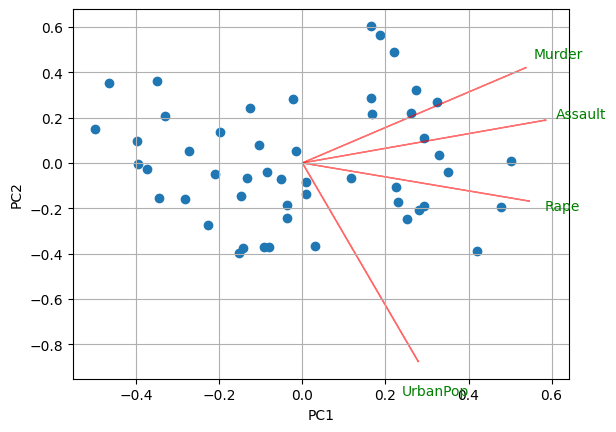

In [ ]:
biplot(us_arrests_pca, np.transpose(pca.components_[0:2, :]), labels=us_arrests.columns)